# Reading ERA5 observations

This notebook introduces how to use the `hydropandas` package to read, process
and visualise ERA5 reanalysis data. ERA5 is produced by the European Centre for
Medium-Range Weather Forecasts (ECMWF) and provides global climate data since
1940. Data are retrieved through the Open-Meteo ERA5 archive API, so no account
or API key is required.

In [1]:
import contextily as ctx
import matplotlib.pyplot as plt

import hydropandas as hpd

# enabling logging so we can see what happens in the background
hpd.util.get_color_logger("INFO");

## Read ERA5 data for a single point

Pass `xy=(longitude, latitude)` to download ERA5 data for the nearest grid
point. The default variable is `precipitation_sum` (daily totals in metres).
Timestamps are shifted to the end of each aggregation period (+1 day for daily
data, consistent with the KNMI convention used throughout hydropandas).

In [2]:
# download daily ERA5 precipitation for De Bilt (NL)
oc = hpd.read_era5(
    xy=(5.18, 52.10),  # (longitude, latitude) in WGS84
    epsg=4326,
    variables=("precipitation_sum",),
    tmin="2020-01-01",
    tmax="2020-12-31",
)
oc

era5 point: 100%|██████████| 1/1 [00:00<00:00,  5.96it/s]


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
ERA5_52.1000_5.1800_precipitation_sum,5.18,52.1,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.1000_5.1800_precipitation_sum...


Grid point  lon=5.18  lat=52.10  unit=m


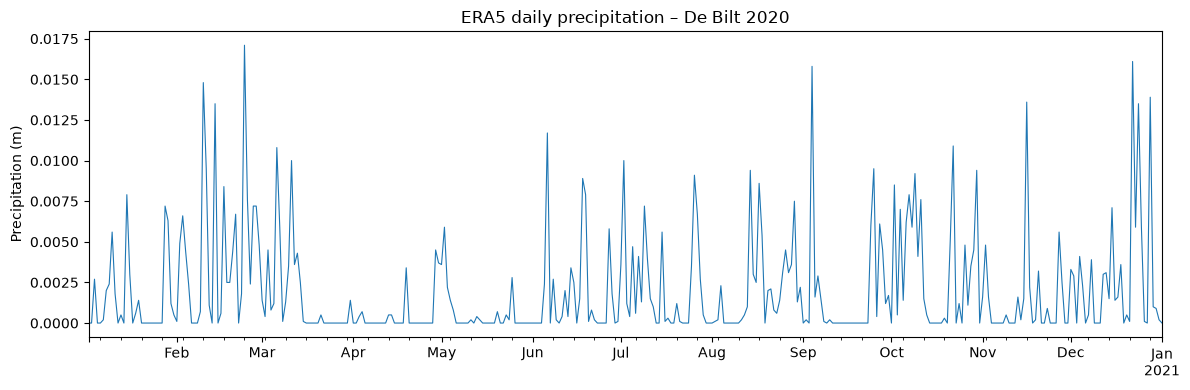

In [3]:
# plot the precipitation time series
o = oc.iloc[0].obs
print(f"Grid point  lon={o.x:.2f}  lat={o.y:.2f}  unit={o.unit}")

o["precipitation_sum"].plot(
    figsize=(12, 4),
    linewidth=0.8,
    ylabel="Precipitation (m)",
    title="ERA5 daily precipitation – De Bilt 2020",
)
plt.tight_layout()

## Read ERA5 data for an extent

Pass an `extent` to download data for all ERA5 grid points within a bounding
box. The `grid_size` parameter (default 0.25°) controls the spacing between
grid points. Use `keep_all_obs=True` to retain points that have no data.

In [18]:
# read ERA5 data for a small extent around the Netherlands
# extent: [xmin, xmax, ymin, ymax] in WGS84
extent = [4.5, 5.1, 51.8, 52.2]

oc_extent = hpd.read_era5(
    extent=extent,
    epsg=4326,
    variables=("precipitation_sum",),
    tmin="2020-01-01",
    tmax="2020-01-31",
    grid_size=0.25,
    keep_all_obs=True,
)
oc_extent

era5 point: 100%|██████████| 9/9 [00:04<00:00,  2.09it/s]


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
ERA5_51.8000_4.5000_precipitation_sum,4.50,51.80,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_51.8000_4.5000_precipitation_sum...
ERA5_52.0500_4.5000_precipitation_sum,4.50,52.05,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.0500_4.5000_precipitation_sum...
ERA5_52.3000_4.5000_precipitation_sum,4.50,52.30,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.3000_4.5000_precipitation_sum...
ERA5_51.8000_4.7500_precipitation_sum,4.75,51.80,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_51.8000_4.7500_precipitation_sum...
ERA5_52.0500_4.7500_precipitation_sum,4.75,52.05,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.0500_4.7500_precipitation_sum...
ERA5_52.3000_4.7500_precipitation_sum,4.75,52.30,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.3000_4.7500_precipitation_sum...
ERA5_51.8000_5.0000_precipitation_sum,5.00,51.80,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_51.8000_5.0000_precipitation_sum...
ERA5_52.0500_5.0000_precipitation_sum,5.00,52.05,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.0500_5.0000_precipitation_sum...
ERA5_52.3000_5.0000_precipitation_sum,5.00,52.30,,,ERA5,m,NaN,precipitation_sum,MeteoObs ERA5_52.3000_5.0000_precipitation_sum...


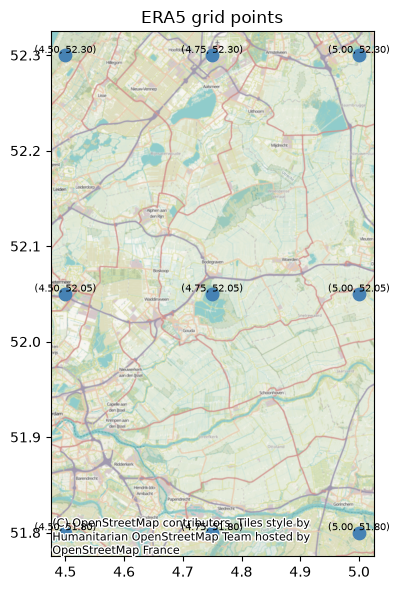

In [5]:
# plot grid point locations on a map
ax = oc_extent.to_gdf(crs=4326).plot(
    figsize=(8, 6), color="steelblue", markersize=80, zorder=2
)
ctx.add_basemap(ax=ax, crs=4326)

for idx, row in oc_extent.iterrows():
    ax.annotate(
        text=f"({row['x']:.2f}, {row['y']:.2f})",
        xy=(row["x"], row["y"]),
        fontsize=7,
        ha="center",
        va="bottom",
    )
ax.set_title("ERA5 grid points")
plt.tight_layout()

## Download multiple variables

Pass a list of variable names to the `variables` argument. Available daily
variables include (among others):

| Variable | Description |
|---|---|
| `precipitation_sum` | Total precipitation (m) |
| `temperature_2m_max` | Maximum 2 m air temperature (°C) |
| `temperature_2m_min` | Minimum 2 m air temperature (°C) |
| `wind_speed_10m_max` | Maximum 10 m wind speed (m/s) |
| `et0_fao_evapotranspiration` | Reference evapotranspiration (mm) |

era5 point: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


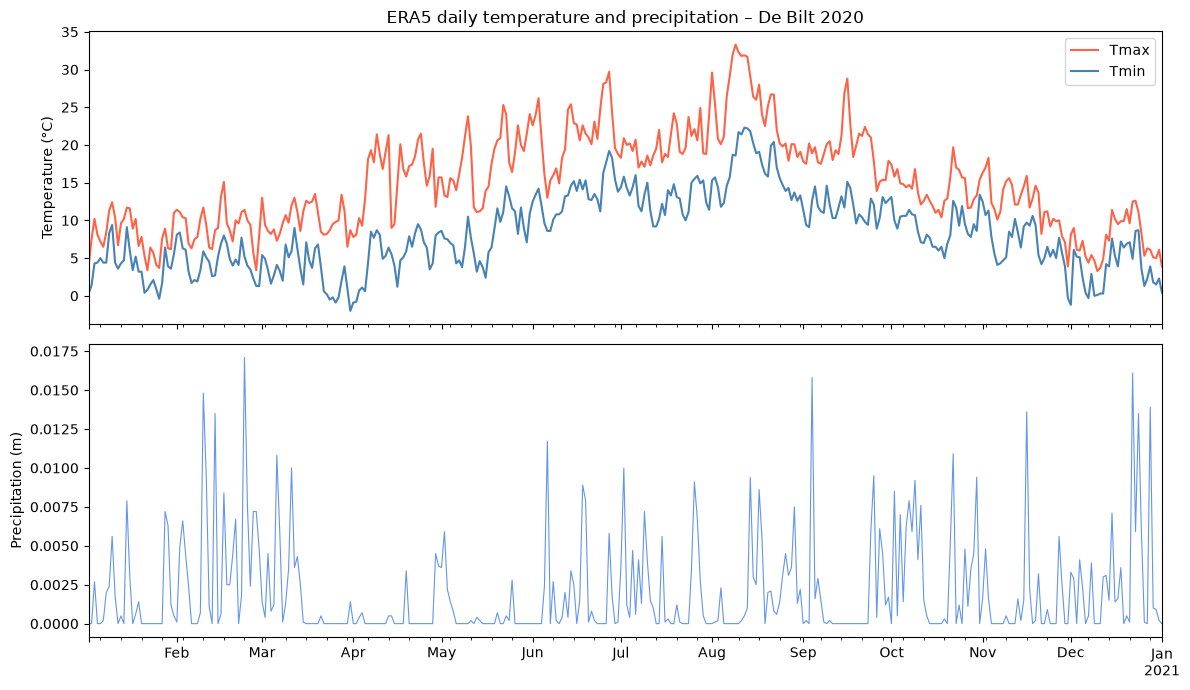

In [6]:
# download temperature and precipitation for De Bilt
oc_multi = hpd.read_era5(
    xy=(5.18, 52.10),
    epsg=4326,
    variables=("temperature_2m_max", "temperature_2m_min", "precipitation_sum"),
    tmin="2020-01-01",
    tmax="2020-12-31",
)

o_temp_max = oc_multi.get_obs(meteo_var="temperature_2m_max")
o_temp_min = oc_multi.get_obs(meteo_var="temperature_2m_min")
o_prec = oc_multi.get_obs(meteo_var="precipitation_sum")
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# temperature panel

o_temp_max["temperature_2m_max"].plot(ax=axes[0], label="Tmax", color="tomato")
o_temp_min["temperature_2m_min"].plot(ax=axes[0], label="Tmin", color="steelblue")

axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()
axes[0].set_title("ERA5 daily temperature and precipitation – De Bilt 2020")

# precipitation panel
o_prec["precipitation_sum"].plot(ax=axes[1], color="cornflowerblue", linewidth=0.8)
axes[1].set_ylabel("Precipitation (m)")

plt.tight_layout()

## Hourly ERA5 data

Set `source='era5_hourly'` (or `interval='hourly'`) to download sub-daily data.
Timestamps are shifted by +1 hour so the index represents the end of the hourly
aggregation period.

era5 point: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]

interval: hourly  |  source: era5_hourly


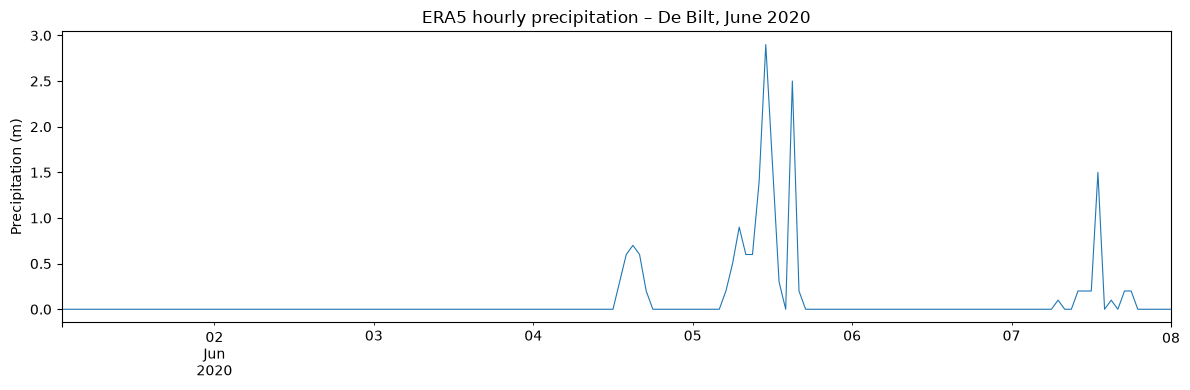

In [7]:
# download hourly ERA5 precipitation for a single week
oc_hourly = hpd.read_era5(
    xy=(5.18, 52.10),
    epsg=4326,
    variables=("precipitation",),
    source="era5_hourly",
    tmin="2020-06-01",
    tmax="2020-06-07",
)

o_hourly = oc_hourly.iloc[0].obs
print(
    f"interval: {o_hourly.meta.get('interval')}  |  source: {o_hourly.meta.get('era5_source')}"
)

o_hourly.iloc[:, 0].plot(
    figsize=(12, 4),
    linewidth=0.8,
    ylabel="Precipitation (m)",
    title="ERA5 hourly precipitation – De Bilt, June 2020",
)
plt.tight_layout()

In [ ]:
# interactive map of the downloaded grid points
oc_extent[["lat", "lon"]] = oc_extent[["y", "x"]]
oc_extent.plots.interactive_map(per_location=False, popup_width=300)